In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Food_Delivery_Times.csv")
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [3]:
df.shape

(1000, 9)

In [4]:
df.columns

Index(['Order_ID', 'Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day',
       'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs',
       'Delivery_Time_min'],
      dtype='object')

In [5]:
df.isnull().sum()

,0
Order_ID,0
Distance_km,0
Weather,30
Traffic_Level,30
Time_of_Day,30
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,30
Delivery_Time_min,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


In [7]:
df['Weather'].value_counts()
df['Traffic_Level'].value_counts()
df['Courier_Experience_yrs'].value_counts()

,count
Courier_Experience_yrs,
6.0,109
9.0,108
1.0,107
8.0,101
2.0,99
4.0,94
0.0,91
7.0,91
5.0,90


In [8]:
categorical_cols = ["Weather","Traffic_Level","Time_of_Day"]

In [9]:
for cols in categorical_cols:
  df[cols] = df[cols].fillna(df[cols].mode()[0])

In [10]:
df["Courier_Experience_yrs"] = df["Courier_Experience_yrs"].fillna(df["Courier_Experience_yrs"].mode())

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 1000 non-null   object 
 3   Traffic_Level           1000 non-null   object 
 4   Time_of_Day             1000 non-null   object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


In [12]:
df['Courier_Experience_yrs'] = df['Courier_Experience_yrs'].fillna(df['Courier_Experience_yrs'].mode()[0])

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 1000 non-null   object 
 3   Traffic_Level           1000 non-null   object 
 4   Time_of_Day             1000 non-null   object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  1000 non-null   float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


### Feature Analysis for Prediction

Let's visualize the distribution of our target variable, `Delivery_Time_min`, first. Then we'll explore its relationships with other features to identify potential predictors.

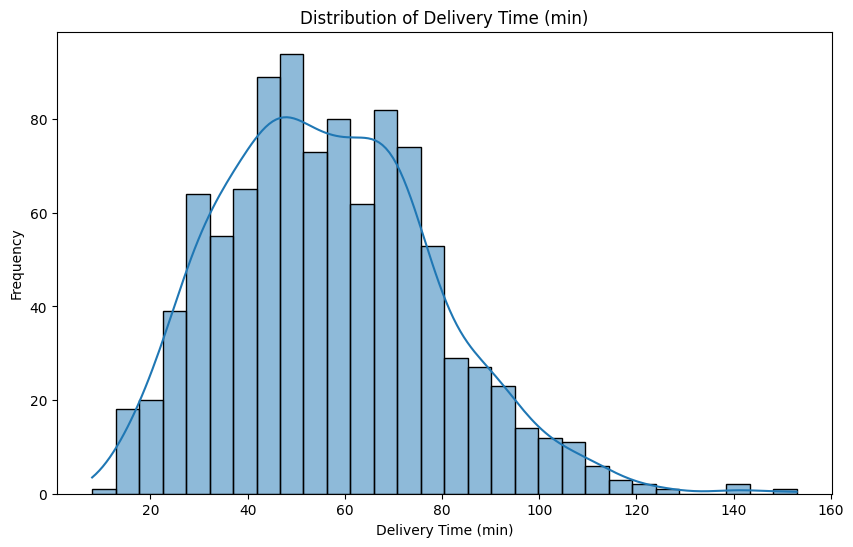

In [14]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Delivery_Time_min'], kde=True, bins=30)
plt.title('Distribution of Delivery Time (min)')
plt.xlabel('Delivery Time (min)')
plt.ylabel('Frequency')
plt.show()

### Relationship with Numerical Features

Now, let's explore how `Delivery_Time_min` relates to other numerical features like `Distance_km`, `Preparation_Time_min`, and `Courier_Experience_yrs` using scatter plots.

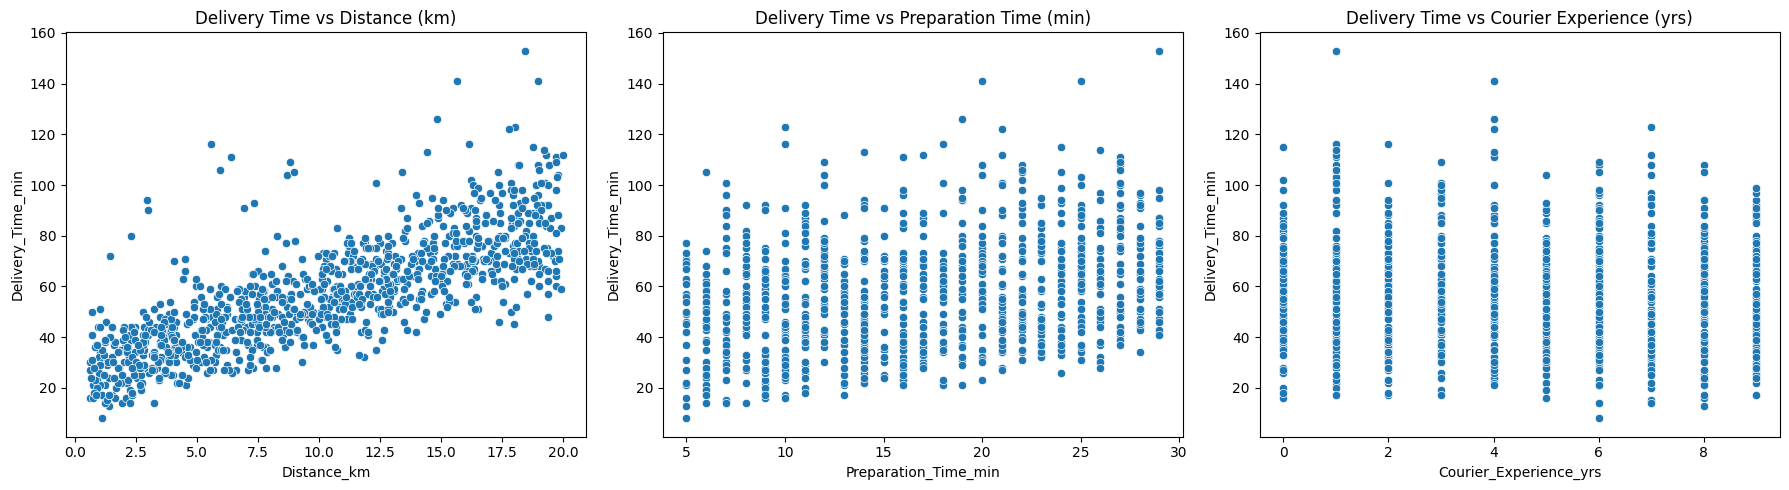

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(x='Distance_km', y='Delivery_Time_min', data=df, ax=axes[0])
axes[0].set_title('Delivery Time vs Distance (km)')

sns.scatterplot(x='Preparation_Time_min', y='Delivery_Time_min', data=df, ax=axes[1])
axes[1].set_title('Delivery Time vs Preparation Time (min)')

sns.scatterplot(x='Courier_Experience_yrs', y='Delivery_Time_min', data=df, ax=axes[2])
axes[2].set_title('Delivery Time vs Courier Experience (yrs)')

plt.tight_layout()
plt.show()

### Relationship with Categorical Features

Finally, let's examine the relationship between `Delivery_Time_min` and categorical features like `Weather`, `Traffic_Level`, `Time_of_Day`, and `Vehicle_Type` using box plots.

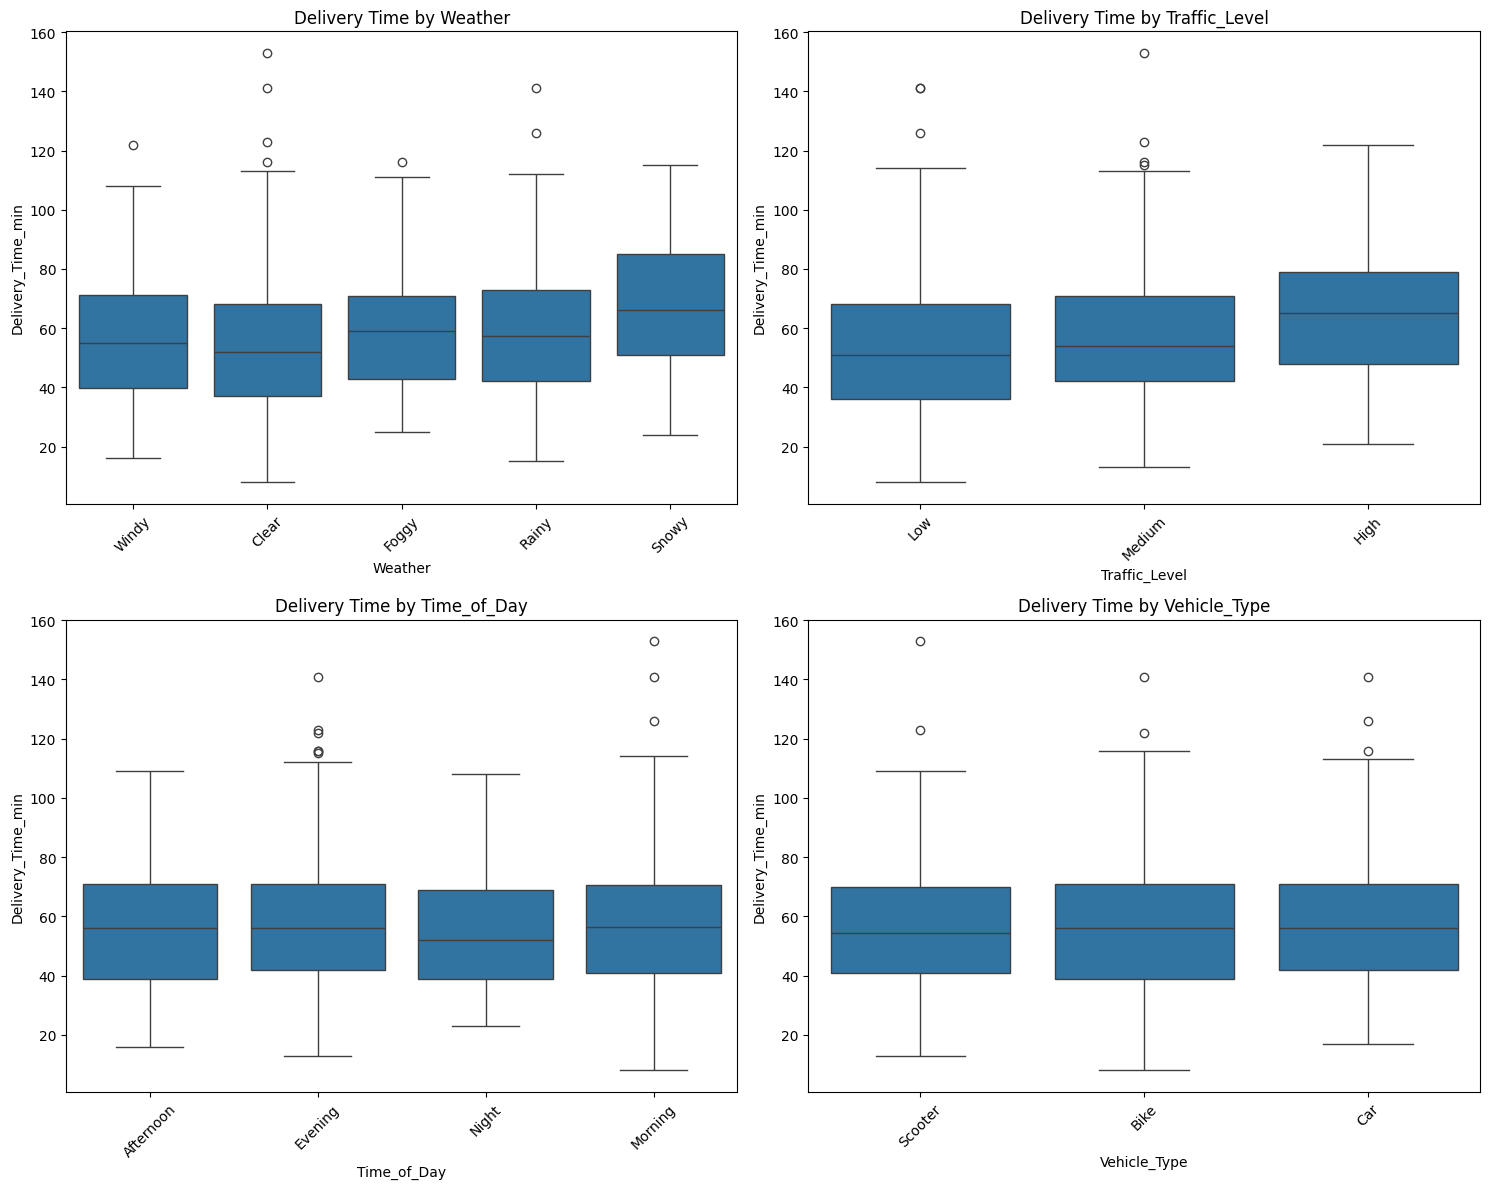

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

categorical_features = ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']

for i, feature in enumerate(categorical_features):
    sns.boxplot(x=feature, y='Delivery_Time_min', data=df, ax=axes[i])
    axes[i].set_title(f'Delivery Time by {feature}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Summary of Predictive Features

Based on the visualizations, here's an analysis of each feature's potential for predicting `Delivery_Time_min`:

*   **Distance_km**: The scatter plot shows a clear positive correlation. As the distance increases, the delivery time generally increases. This is a strong candidate for a predictor.

*   **Preparation_Time_min**: Similar to `Distance_km`, there's a strong positive correlation with `Delivery_Time_min`. Longer preparation times lead to longer overall delivery times. This is also a strong candidate.

*   **Courier_Experience_yrs**: The scatter plot for courier experience versus delivery time appears to show a slight negative trend or perhaps no strong linear correlation. More experienced couriers might be slightly faster, but the relationship isn't as pronounced as distance or preparation time. It might still be a useful feature, possibly with a non-linear relationship or after further analysis.

*   **Weather**: The box plots indicate that different weather conditions (e.g., Snowy, Rainy, Windy) can influence delivery times, with some conditions showing higher average delivery times or greater variance. This is a valuable categorical feature for prediction.

*   **Traffic_Level**: As expected, higher traffic levels (e.g., High, Medium) generally correspond to longer delivery times, as shown by the box plots. This is another strong categorical predictor.

*   **Time_of_Day**: Delivery times vary significantly across different times of the day (e.g., Morning, Afternoon, Evening, Night). This categorical feature also appears to be a good predictor.

*   **Vehicle_Type**: The box plots suggest that different vehicle types (e.g., Scooter, Bike, Car) have varying delivery time distributions, with Cars potentially having higher delivery times than Bikes or Scooters. This is a relevant categorical feature.

**In summary, `Distance_km`, `Preparation_Time_min`, `Weather`, `Traffic_Level`, `Time_of_Day`, and `Vehicle_Type` all show clear relationships with `Delivery_Time_min` and are strong candidates for inclusion in a predictive model. `Courier_Experience_yrs` shows a less direct relationship but could still be considered.**

### Distribution of `Delivery_Time_min`

Let's visualize the distribution of our target variable, `Delivery_Time_min`, using a histogram and a kernel density estimate (KDE) plot.

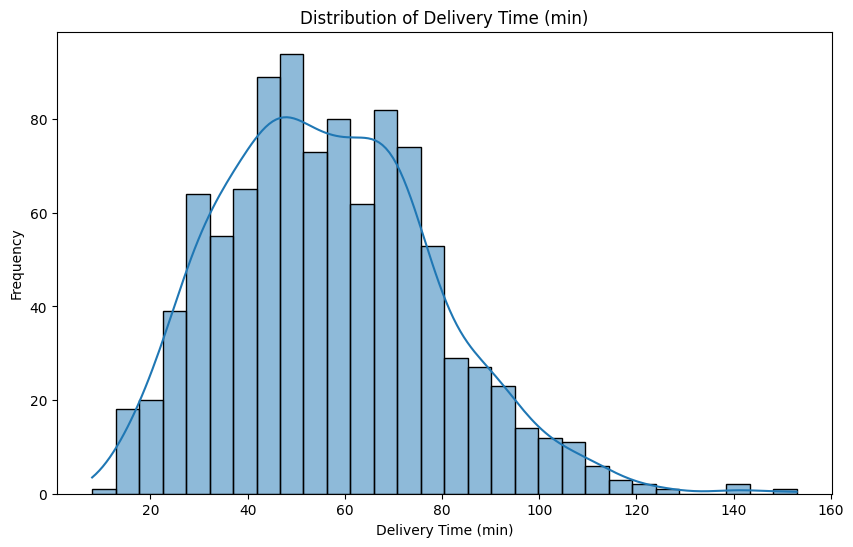

In [17]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Delivery_Time_min'], kde=True, bins=30)
plt.title('Distribution of Delivery Time (min)')
plt.xlabel('Delivery Time (min)')
plt.ylabel('Frequency')
plt.show()

### Relationship with Numerical Features

Now, let's explore how `Delivery_Time_min` relates to other numerical features like `Distance_km`, `Preparation_Time_min`, and `Courier_Experience_yrs` using scatter plots.

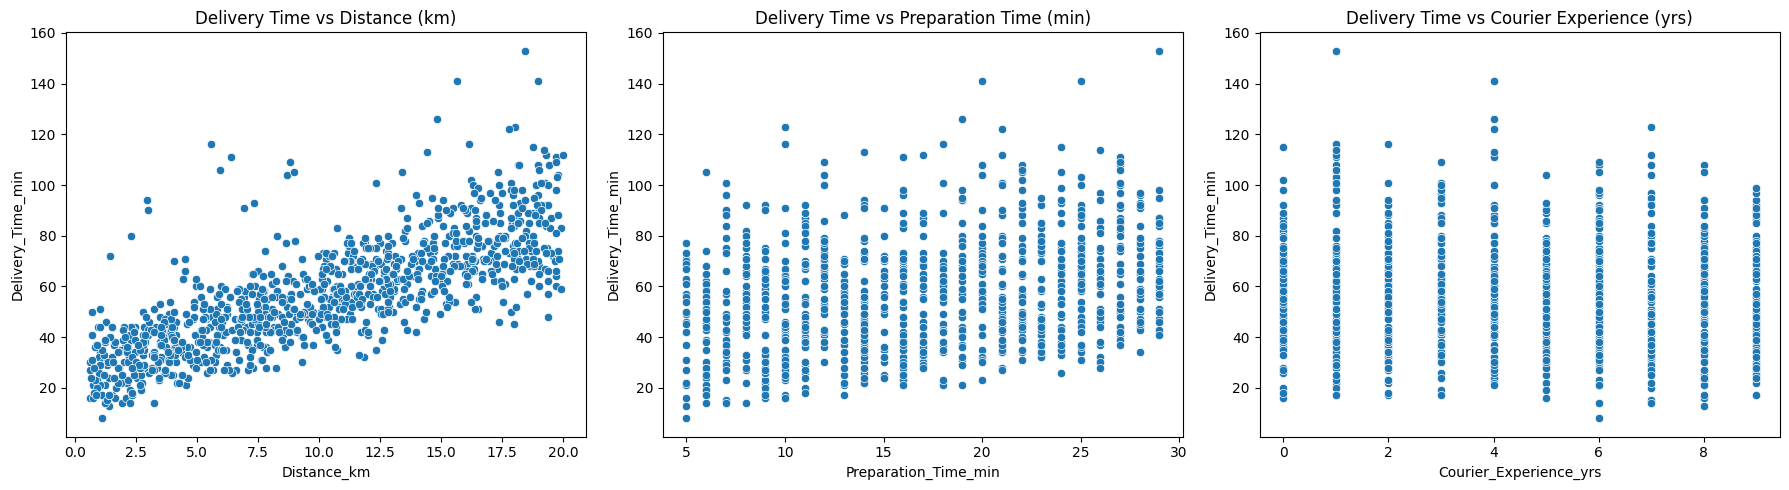

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(x='Distance_km', y='Delivery_Time_min', data=df, ax=axes[0])
axes[0].set_title('Delivery Time vs Distance (km)')

sns.scatterplot(x='Preparation_Time_min', y='Delivery_Time_min', data=df, ax=axes[1])
axes[1].set_title('Delivery Time vs Preparation Time (min)')

sns.scatterplot(x='Courier_Experience_yrs', y='Delivery_Time_min', data=df, ax=axes[2])
axes[2].set_title('Delivery Time vs Courier Experience (yrs)')

plt.tight_layout()
plt.show()

### Relationship with Categorical Features

Finally, let's examine the relationship between `Delivery_Time_min` and categorical features like `Weather`, `Traffic_Level`, `Time_of_Day`, and `Vehicle_Type` using box plots.

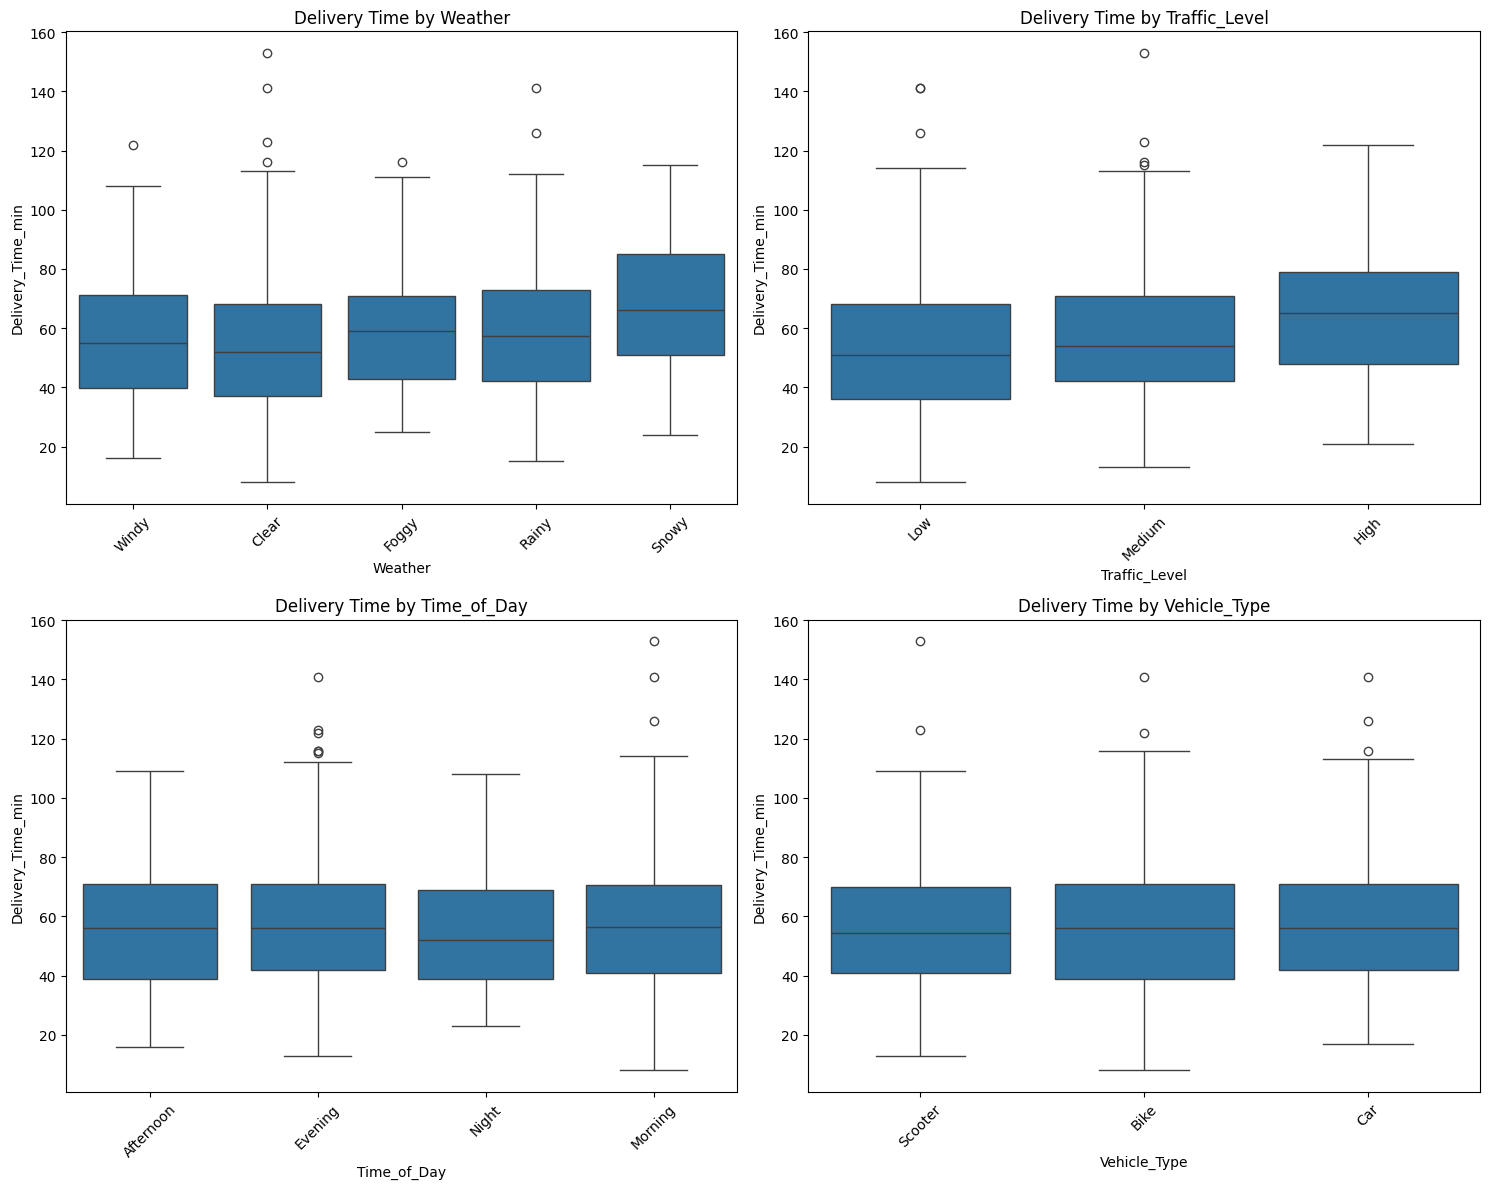

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

categorical_features = ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']

for i, feature in enumerate(categorical_features):
    sns.boxplot(x=feature, y='Delivery_Time_min', data=df, ax=axes[i])
    axes[i].set_title(f'Delivery Time by {feature}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

<Axes: xlabel='Distance_km', ylabel='Delivery_Time_min'>

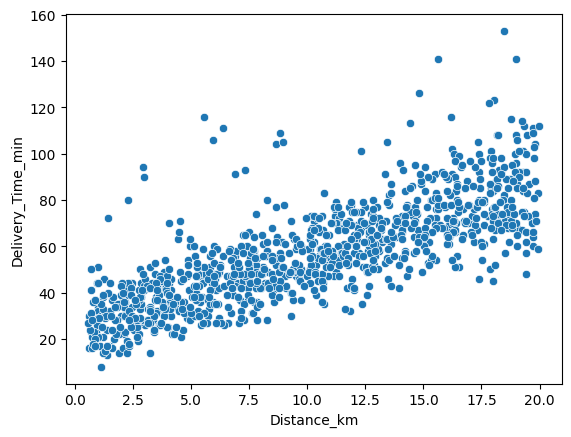

In [20]:
sns.scatterplot(data=df, x="Distance_km",y="Delivery_Time_min")

In [21]:
#1000
#800 rows
#200 rows
from sklearn.model_selection import train_test_split

In [22]:
X = df.drop(["Delivery_Time_min","Order_ID"],axis=1) #ONE HOT ENCODING - CREATING YOUR OWN COLUMN NEW & 0s and 1s mea encode karna
y = df["Delivery_Time_min"] #LABEL ENCODING-

In [23]:
X_encoded = pd.get_dummies(X, columns=['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type'], drop_first=True)
display(X_encoded.head())

,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Windy,Traffic_Level_Low,Traffic_Level_Medium,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Vehicle_Type_Car,Vehicle_Type_Scooter
0,7.93,12,1.0,False,False,False,True,True,False,False,False,False,False,True
1,16.42,20,2.0,False,False,False,False,False,True,True,False,False,False,False
2,9.52,28,1.0,True,False,False,False,True,False,False,False,True,False,True
3,7.44,5,1.0,False,True,False,False,False,True,False,False,False,False,True
4,19.03,16,5.0,False,False,False,False,True,False,False,True,False,False,False


In [24]:
X_encoded = X_encoded.astype(int)

In [25]:
X_encoded

,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Windy,Traffic_Level_Low,Traffic_Level_Medium,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Vehicle_Type_Car,Vehicle_Type_Scooter
0,7,12,1,0,0,0,1,1,0,0,0,0,0,1
1,16,20,2,0,0,0,0,0,1,1,0,0,0,0
2,9,28,1,1,0,0,0,1,0,0,0,1,0,1
3,7,5,1,0,1,0,0,0,1,0,0,0,0,1
4,19,16,5,0,0,0,0,1,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,8,13,3,0,0,0,0,0,0,1,0,0,1,0
996,16,8,9,0,1,0,0,1,0,0,1,0,0,1
997,15,26,2,0,0,1,0,0,0,1,0,0,0,1
998,14,8,0,0,0,0,0,1,0,0,0,0,0,0


The line `X_encoded = pd.get_dummies(X, columns=['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type'], drop_first=True)` does the following:

*   **`pd.get_dummies(X, ...)`**: This is a pandas function used to convert categorical variables into dummy/indicator variables (one-hot encoding).
*   **`columns=['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']`**: This specifies the list of columns from the `X` DataFrame that you want to one-hot encode. For each unique value in these columns, a new binary column will be created.
*   **`drop_first=True`**: This is an important parameter. When set to `True`, it drops the first category for each feature. This is commonly done to avoid multicollinearity (where one dummy variable can be predicted from the others), which can be an issue in some machine learning models.

For example, if 'Weather' had categories 'Sunny', 'Rainy', 'Foggy', and 'Windy', `pd.get_dummies` with `drop_first=True` would create three new columns: `Weather_Rainy`, `Weather_Foggy`, and `Weather_Windy`. If a row has 'Sunny' weather, all three new columns would be 0.

In [26]:
X.head()

,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs
0,7.93,Windy,Low,Afternoon,Scooter,12,1.0
1,16.42,Clear,Medium,Evening,Bike,20,2.0
2,9.52,Foggy,Low,Night,Scooter,28,1.0
3,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0
4,19.03,Clear,Low,Morning,Bike,16,5.0


In [27]:
y.head()

,Delivery_Time_min
0,43
1,84
2,59
3,37
4,68


In [28]:
#OHE


In [29]:
X_train,X_test,y_train,y_test = train_test_split(X_encoded,y,test_size=0.20,random_state=42)

In [30]:
from sklearn.linear_model import LinearRegression

In [31]:
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [32]:
y_pred = model.predict(X_test)
y_pred #delivery time predictions

array([35.85524506, 66.50618794, 45.99813061, 44.31364082, 80.08536476,
       31.76795533, 70.36826759, 33.84071034, 36.06038913, 78.62634246,
       73.26464652, 59.00347359, 36.11649926, 70.27755733, 89.59089981,
       82.57838829, 34.23421812, 68.93321732, 46.60096151, 60.14005952,
       83.4786694 , 28.39939914, 81.33739699, 78.29118678, 64.10091694,
       32.83308478, 85.7234758 , 25.59882265, 51.5210784 , 66.93903618,
       69.81145074, 16.61374967, 61.56054726, 36.51840067, 68.98522899,
       21.83929791, 61.0234172 , 55.33076297, 46.86657217, 76.75595691,
       77.39111873, 32.4860969 , 80.31575338, 65.04809254, 37.5752306 ,
       16.40175995, 89.87994707, 84.12681258, 78.58041688, 27.45323531,
       63.95345679, 55.83328646, 37.64130977, 81.01502521, 55.42903909,
       52.60154527, 76.52178046, 81.0256841 , 67.08482282, 91.05871724,
       47.52727776, 35.27094651, 48.96726572, 46.95715553, 51.34800371,
       64.3409834 , 63.78490889, 91.60539588, 77.58465666, 57.36

In [33]:
y_test

,Delivery_Time_min
521,32
737,68
740,39
660,44
411,85
...,...
408,78
332,28
208,60
613,45


In [34]:
from sklearn.metrics import r2_score

In [35]:
r2_score(y_test,y_pred)

0.819276975747797